In [1]:
import warnings;
warnings.simplefilter('ignore')
%matplotlib inline


from dcr import *

In [2]:
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = (16,9)
plt.rcParams.update({'font.size':16})

In [6]:
data2 = data[['id', 'time', 'gdp_time', 'FICO_orig_time', 'LTV_time']].round(decimals=2)

In [7]:
print(data2)

          id  time  gdp_time  FICO_orig_time  LTV_time
0          4    25      2.90             587     33.91
1          4    26      2.15             587     34.01
2          4    27      2.36             587     34.34
3          4    28      1.23             587     34.67
4          4    29      1.69             587     34.95
...      ...   ...       ...             ...       ...
62173  49972    52      1.08             708    103.31
62174  49972    53      0.89             708     95.74
62175  49972    54      1.51             708     91.87
62176  49972    55      2.42             708     91.56
62177  49972    56      1.72             708     90.87

[62178 rows x 5 columns]


In [8]:
print(data.shape)

(62178, 28)


In [9]:
print(data.columns.values)

['id' 'time' 'orig_time' 'first_time' 'mat_time' 'res_time' 'balance_time'
 'LTV_time' 'interest_rate_time' 'rate_time' 'hpi_time' 'gdp_time'
 'uer_time' 'REtype_CO_orig_time' 'REtype_PU_orig_time'
 'REtype_SF_orig_time' 'investor_orig_time' 'balance_orig_time'
 'FICO_orig_time' 'LTV_orig_time' 'Interest_Rate_orig_time'
 'state_orig_time' 'hpi_orig_time' 'default_time' 'payoff_time'
 'status_time' 'lgd_time' 'recovery_res']


In [10]:
data2 = data[['FICO_orig_time', 'LTV_orig_time', 'gdp_time']]

print(data2.describe().round(decimals=2))

       FICO_orig_time  LTV_orig_time  gdp_time
count        62178.00       62178.00  62178.00
mean           673.36          78.70      1.38
std             72.10          10.24      1.95
min            429.00          50.10     -4.15
25%            628.00          75.00      1.10
50%            675.00          80.00      1.85
75%            730.00          80.00      2.69
max            819.00         119.80      5.13


In [11]:
table = pd.crosstab(data.orig_time, columns=['count'], margins=True)

print(table)

col_0      count    All
orig_time              
-40           51     51
-35            4      4
-33            3      3
-24            1      1
-23            1      1
...          ...    ...
57             4      4
58             3      3
59            14     14
60             9      9
All        62178  62178

[73 rows x 2 columns]


In [12]:
data2 = data
data2.loc[:, 'orig_time2'] = data2.loc[:, 'orig_time']

data2.loc[data2['orig_time2'] < 0, 'orig_time2'] = 0
data2.loc[data2['orig_time2'] >= 30, 'orig_time2'] = 30

default_rate = data2.groupby('orig_time2')['FICO_orig_time'].mean().reset_index(drop=False)
print(data.shape)

(62178, 29)


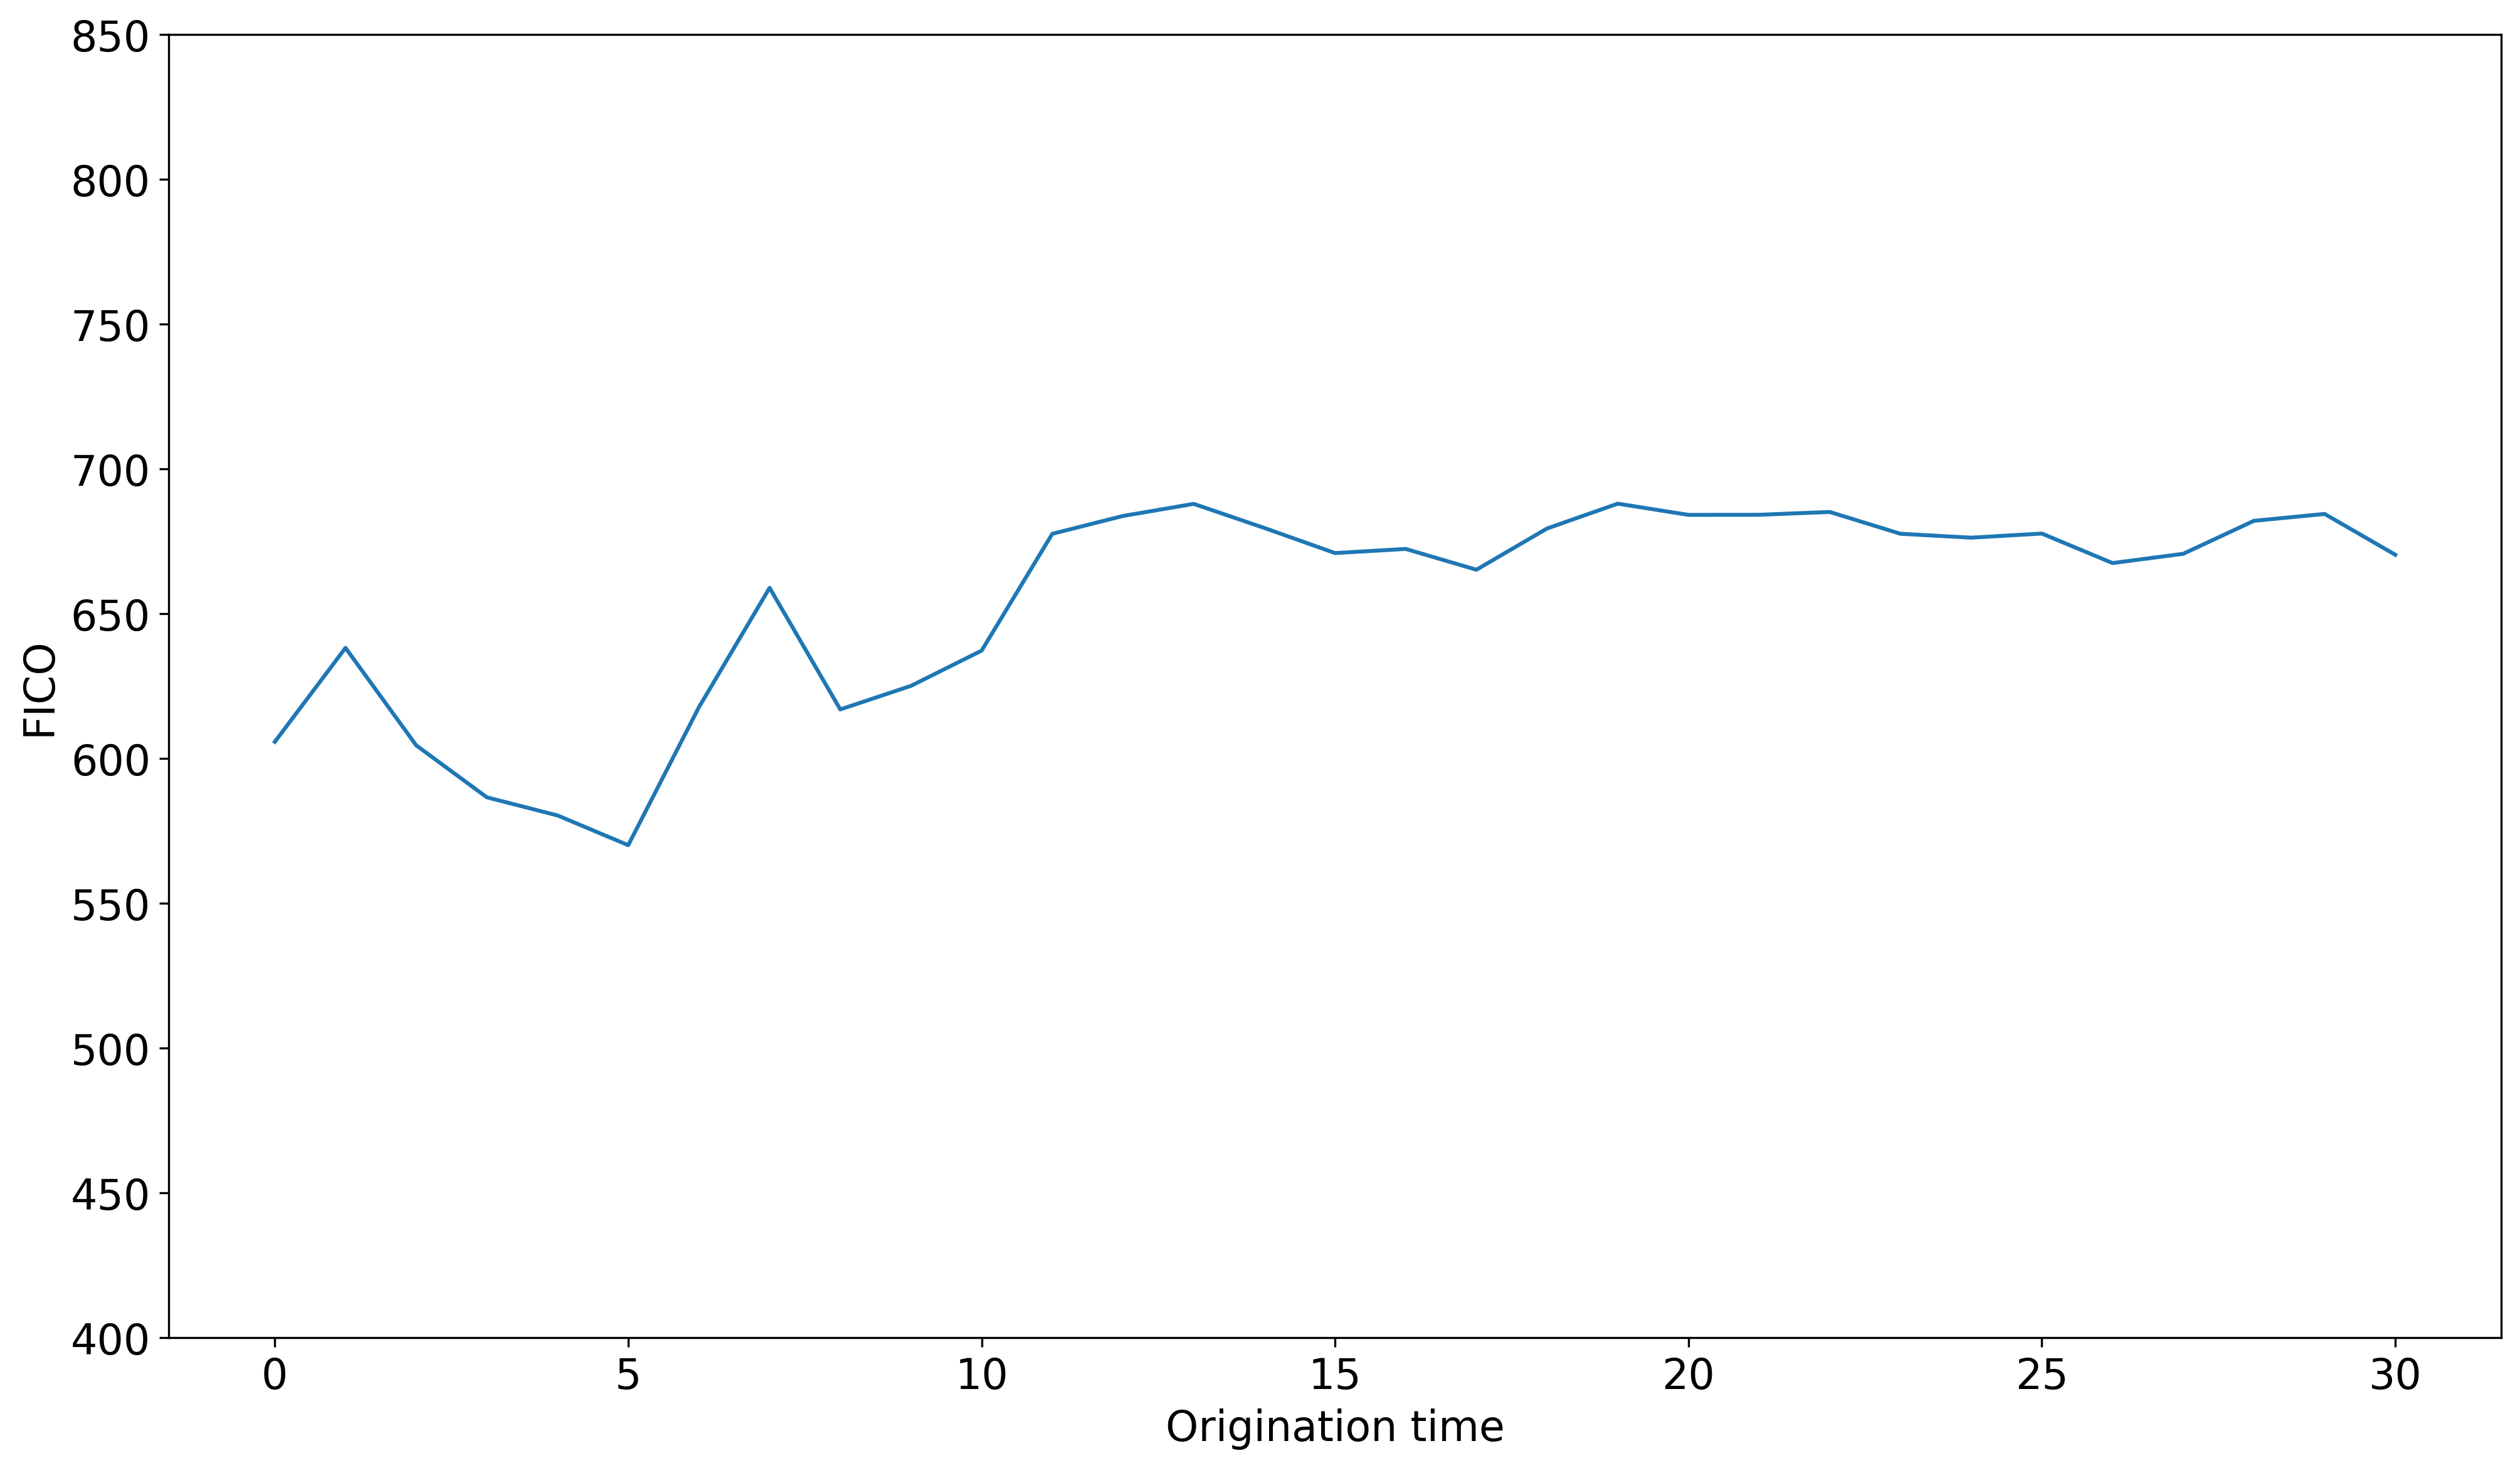

In [14]:
plt.plot('orig_time2', 'FICO_orig_time', data=default_rate)
plt.xlabel('Origination time')
plt.ylabel('FICO')
plt.ylim([400,850])
plt.show()

In [15]:
data.loc[: , 'dummy'] = 0

In [17]:
data.loc[data['LTV_orig_time'] > 70, 'dummy'] = 1

In [18]:
print(data[['LTV_orig_time']].round(decimals=2))

       LTV_orig_time
0               81.8
1               81.8
2               81.8
3               81.8
4               81.8
...              ...
62173           79.8
62174           79.8
62175           79.8
62176           79.8
62177           79.8

[62178 rows x 1 columns]


In [19]:
data.loc[:, 'FICO_orig_time2'] = data.loc[:, 'FICO_orig_time']+10

print(data[['FICO_orig_time', 'FICO_orig_time2']].round(decimals=2))

       FICO_orig_time  FICO_orig_time2
0                 587              597
1                 587              597
2                 587              597
3                 587              597
4                 587              597
...               ...              ...
62173             708              718
62174             708              718
62175             708              718
62176             708              718
62177             708              718

[62178 rows x 2 columns]


In [20]:
data.loc[:, 'FICO_orig_time2'] = data.loc[:, 'FICO_orig_time']

data.loc[data['FICO_orig_time2'] <= 600, 'FICO_orig_time2'] = 600

data.loc[data['FICO_orig_time2'] >= 700, 'FICO_orig_time2'] = 700

In [21]:
print(data[['FICO_orig_time', 'FICO_orig_time2']].round(decimals=2))

       FICO_orig_time  FICO_orig_time2
0                 587              600
1                 587              600
2                 587              600
3                 587              600
4                 587              600
...               ...              ...
62173             708              700
62174             708              700
62175             708              700
62176             708              700
62177             708              700

[62178 rows x 2 columns]


In [22]:
data2 = data[['FICO_orig_time']]

print(data2.shape)

(62178, 1)


In [23]:
data2 = data.loc[:, 'FICO_orig_time'].copy()
data2 = data.iloc[:, 19].copy()
print(data2.shape)

(62178,)


In [24]:
data2 = data.loc[0, :].copy()
data2 = data.iloc[0, :].copy()

print(data2.shape)

(31,)


In [25]:
data2 = data.query('FICO_orig_time >= 800').copy()

print(data2.index)

Index([   53,    54,    55,    56,    67,    71,  3244,  3245,  3246,  3247,
       ...
       61844, 61873, 61874, 61875, 61876, 61877, 61878, 61879, 61880, 61881],
      dtype='int64', length=838)


In [26]:
data2 = data.sample(100, random_state=12345)

print(data2.shape)

(100, 31)


In [27]:
data2 = data.drop('LTV_orig_time', axis='columns').copy()

print(data2.shape)

(62178, 30)


In [28]:
data2 = data.drop(0, axis='rows').copy()

print(data2.shape)

(62177, 31)


In [29]:
data2 = data2.reset_index(drop=True)
print(data2.index)

RangeIndex(start=0, stop=62177, step=1)


In [31]:
hpi_time = data.loc[:, ['time', 'hpi_time']].drop_duplicates().reset_index(drop=True)
uer_time = data.loc[:, ['time', 'uer_time']].drop_duplicates().reset_index(drop=True)
gdp_time = data.loc[:, ['time', 'gdp_time']].drop_duplicates().reset_index(drop=True)

macro_time = pd.concat([hpi_time, uer_time, gdp_time], axis=1)
print(macro_time.shape)

(60, 6)


In [32]:
macro_time2 = pd.concat([hpi_time, hpi_time], axis=0)

print(macro_time2.shape)

(120, 2)


In [34]:
#macro_time2 = hpi_time.append(hpi_time)

#print(macro_time2.shape)

In [35]:
data_orig_time = data[['id', 'orig_time', 'first_time', 'mat_time', 'res_time', 'REtype_CO_orig_time', 'REtype_PU_orig_time', 'REtype_SF_orig_time',  'investor_orig_time', 'balance_orig_time', 'FICO_orig_time', 'LTV_orig_time', 'Interest_Rate_orig_time', 'state_orig_time', 'hpi_orig_time']].drop_duplicates(subset=  'id', keep='first')  
data_time = data[['id', 'time', 'balance_time', 'LTV_time', 'interest_rate_time', 'rate_time', 'default_time', 'payoff_time', 'status_time', 'lgd_time', 'recovery_res']]  
macro_time = data[['time', 'hpi_time', 'gdp_time', 'uer_time']].drop_duplicates()

In [36]:
print('data:', data.shape)  
print('data_orig_time:', data_orig_time.shape)  
print('data_time:', data_time.shape)  
print('macro_time:', macro_time.shape)

data: (62178, 31)
data_orig_time: (5000, 15)
data_time: (62178, 11)
macro_time: (60, 4)


In [37]:
data2 = pd.merge(data_orig_time, data_time, on='id') 
data3 = pd.merge(data2, macro_time, on='time') 
print('Original dataframe data:', data.shape) 
print('Reconstituted dataframe data3:', data3.shape)

Original dataframe data: (62178, 31)
Reconstituted dataframe data3: (62178, 28)


In [38]:
hpi_time = data.loc[:,['time', 'hpi_time']].drop_duplicates().reset_index(drop=True)  
uer_time = data.loc[:,['time', 'uer_time']].drop_duplicates().reset_index(drop=True)  
macro_time3 = hpi_time.set_index('time').join(uer_time.set_index('time'), on='time')  
print(macro_time3.shape) 
 

(60, 2)


In [39]:
data_ols = smf.ols(formula='LTV_time ~ LTV_orig_time + gdp_time', data=data).fit()

In [40]:
print(data_ols.summary())

                            OLS Regression Results                            
Dep. Variable:               LTV_time   R-squared:                       0.220
Model:                            OLS   Adj. R-squared:                  0.220
Method:                 Least Squares   F-statistic:                     8772.
Date:                Fri, 25 Jul 2025   Prob (F-statistic):               0.00
Time:                        18:12:23   Log-Likelihood:            -2.8781e+05
No. Observations:               62153   AIC:                         5.756e+05
Df Residuals:                   62150   BIC:                         5.756e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        13.8450      0.773     17.901

In [41]:
array1 = np.array([1,2])
print(array1)
print(array1.ndim)
print(array1.shape)

[1 2]
1
(2,)


In [42]:
array2 = np.array([[1,3], [2,4]])
print(array2)
print(array2.ndim)
print(array2.shape)

[[1 3]
 [2 4]]
2
(2, 2)


In [43]:
print(array2[0,])

[1 3]


In [44]:
print(array2[:, 1])

[3 4]


In [45]:
print(array2[1,0])

2


In [46]:
data2 = data[['id', 'time', 'gdp_time', 'FICO_orig_time', 'LTV_time']].round(decimals=2)  
clabels = data2.columns.values  
data_numpy = data2.values  
print(data_numpy)

[[4.0000e+00 2.5000e+01 2.9000e+00 5.8700e+02 3.3910e+01]
 [4.0000e+00 2.6000e+01 2.1500e+00 5.8700e+02 3.4010e+01]
 [4.0000e+00 2.7000e+01 2.3600e+00 5.8700e+02 3.4340e+01]
 ...
 [4.9972e+04 5.4000e+01 1.5100e+00 7.0800e+02 9.1870e+01]
 [4.9972e+04 5.5000e+01 2.4200e+00 7.0800e+02 9.1560e+01]
 [4.9972e+04 5.6000e+01 1.7200e+00 7.0800e+02 9.0870e+01]]


In [47]:
data=pd.DataFrame(data=data_numpy, columns=clabels)  
print(data)

            id  time  gdp_time  FICO_orig_time  LTV_time
0          4.0  25.0      2.90           587.0     33.91
1          4.0  26.0      2.15           587.0     34.01
2          4.0  27.0      2.36           587.0     34.34
3          4.0  28.0      1.23           587.0     34.67
4          4.0  29.0      1.69           587.0     34.95
...        ...   ...       ...             ...       ...
62173  49972.0  52.0      1.08           708.0    103.31
62174  49972.0  53.0      0.89           708.0     95.74
62175  49972.0  54.0      1.51           708.0     91.87
62176  49972.0  55.0      2.42           708.0     91.56
62177  49972.0  56.0      1.72           708.0     90.87

[62178 rows x 5 columns]
